--- 국내 반응 수집 시작 ---
[ko] 트위터 검색 URL 접속 중...


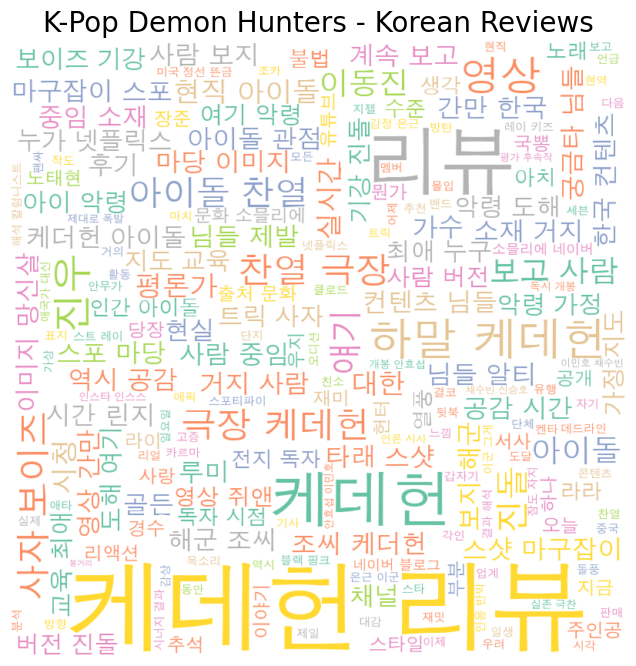

--- 해외 반응 수집 시작 ---
[en] 트위터 검색 URL 접속 중...


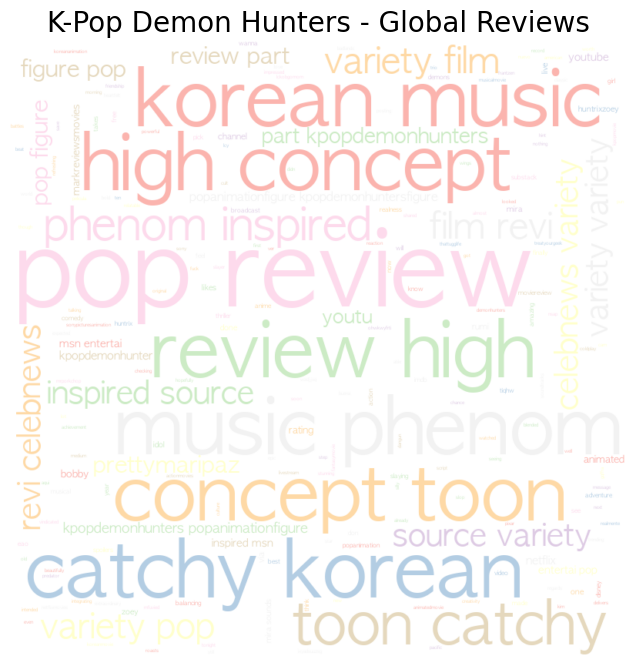

In [5]:
### 2. 한/영 리뷰 수집 및 워드클라우드 분석 파이프라인


import pandas as pd
import time
import re
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from konlpy.tag import Okt
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

class KpopDemonHunterAnalyzer:
    def __init__(self):
        self.okt = Okt()
        # 한국어 불용어 (분석에 의미 없는 단어들)
        self.ko_stopwords = set(['진짜', '너무', '정말', '이거', '그냥', '영화', '애니', '데몬', '헌터스', '케이팝'])
        # 영어 불용어 추가 (기본 STOPWORDS에 추가)
        self.en_stopwords = set(STOPWORDS)
        self.en_stopwords.update(['movie', 'animation', 'kpop', 'demon', 'hunters', 'just', 'really', 'like'])

    def clean_text_ko(self, text):
        """한국어 텍스트 정제 및 명사 추출"""
        text = re.sub(r'[^가-힣\s]', ' ', text)
        nouns = self.okt.nouns(text)
        # 불용어 제거 및 2글자 이상 단어만 추출
        words = [n for n in nouns if n not in self.ko_stopwords and len(n) > 1]
        return " ".join(words)

    def clean_text_en(self, text):
        """영어 텍스트 정제"""
        text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
        words = text.split()
        words = [w for w in words if w not in self.en_stopwords and len(w) > 2]
        return " ".join(words)

    def generate_wordcloud(self, text_data, language, title):
        """워드클라우드 생성기"""
        # MAC 환경의 한글 폰트 경로 설정 (영어는 기본 폰트 사용 가능하지만 통일)
        font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf' 
        
        wc = WordCloud(
            font_path=font_path,
            width=800, height=800,
            background_color='white',
            colormap='Set2' if language == 'ko' else 'Pastel1' # 국가별 색상 차별화
        )
        
        wordcloud = wc.generate(text_data)
        
        plt.figure(figsize=(8, 8))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(title, fontsize=20)
        plt.axis('off')
        plt.show()

def scrape_twitter_reviews(search_url, lang):
    """실행 중인 크롬(디버깅 모드)과 연결하여 트위터 크롤링"""
    
    # 1. 디버깅 모드로 열려있는 크롬과 연결
    chrome_options = Options()
    chrome_options.add_experimental_option("debuggerAddress", "127.0.0.1:9222")
    driver = webdriver.Chrome(options=chrome_options)
    
    analyzer = KpopDemonHunterAnalyzer()
    collected_words = []
    
    try:
        print(f"[{lang}] 트위터 검색 URL 접속 중...")
        driver.get(search_url)
        time.sleep(5) # 검색 결과 로딩 대기
        
        # 무한 스크롤
        for i in range(10): # 필요에 따라 스크롤 횟수 증가
            # 트위터 본문 CSS 선택자 (트위터 UI 변경에 따라 바뀔 수 있음)
            tweets = driver.find_elements(By.CSS_SELECTOR, '[data-testid="tweetText"]')
            
            for tweet in tweets:
                try:
                    text = tweet.text
                    if lang == 'ko':
                        cleaned = analyzer.clean_text_ko(text)
                    else:
                        cleaned = analyzer.clean_text_en(text)
                    
                    if cleaned:
                        collected_words.append(cleaned)
                except:
                    continue
            
            # 스크롤 내리기
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(3) # 트위터는 스크롤 후 렌더링이 느리므로 충분히 대기
            
    except Exception as e:
        print(f"크롤링 에러 발생: {e}")
        
    # 크롬은 닫지 않음 (세션 유지)
    return " ".join(collected_words)

# ==========================================
# 실행 파트
# ==========================================
if __name__ == "__main__":
    # 트위터 검색 URL (최신순 등 쿼리에 맞게 변경 가능)
    url_ko = 'https://x.com/search?q=케데헌%20리뷰&src=typed_query&f=live'
    url_en = 'https://x.com/search?q="K-Pop%20Demon%20Hunters%20Review"&src=typed_query&f=live'
    
    analyzer = KpopDemonHunterAnalyzer()
    
    # 1. 국내(한국어) 반응 수집 및 워드클라우드
    print("--- 국내 반응 수집 시작 ---")
    ko_text_data = scrape_twitter_reviews(url_ko, lang='ko')
    if ko_text_data:
        analyzer.generate_wordcloud(ko_text_data, 'ko', 'K-Pop Demon Hunters - Korean Reviews')
    
    # 2. 해외(영어) 반응 수집 및 워드클라우드
    print("--- 해외 반응 수집 시작 ---")
    en_text_data = scrape_twitter_reviews(url_en, lang='en')
    if en_text_data:
        analyzer.generate_wordcloud(en_text_data, 'en', 'K-Pop Demon Hunters - Global Reviews')